# <center>Recommendation Systems</center>


### **Abstract:**

This project will use the Goodbooks-10k dataset, which is available to download from GitHub: https://github.com/zygmuntz/goodbooks-10k 

**Dataset content:**

Book metadata: Information about 10,000 popular books, including title, author, year of publication, average rating and book IDs.

Ratings: Approximately six million ratings provided by users, with each rating containing the user ID, book ID and rating out of five.

The dataset may also include optional information such as user-assigned tags or genres.

This dataset reflects real-world user behaviour and preferences, making it ideal for analysing recommendation systems based on explicit ratings and book metadata, as well as potentially implicit preferences.

### Import libraries needed

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import ast
import warnings
warnings.filterwarnings('ignore') 

### Reading datasets

In [2]:
books = pd.read_csv("books.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("book_tags.csv")
tag_names = pd.read_csv("tags.csv")


# <center>Pre-processing</center>

#### To get an initial understanding of the datasets and to help identify how I can merge them, the first five rows of the dataframe are displayed.

In [3]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [4]:
ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


In [5]:
tags.head()

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716


In [6]:
tag_names.head()

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-


#### Shapes of each dataset

In [7]:
books.shape

(10000, 23)

In [8]:
ratings.shape

(5976479, 3)

In [9]:
tags.shape


(999912, 3)

In [10]:
tag_names.shape

(34252, 2)

**Note:**

Due to the size of the ratings dataset (approximately 6 million observations), it is necessary to work with a sample.  

The 'book_id' column will be used to merge the books dataset with the ratings dataset. Then, the 'tag_names' and 'tags' datasets will be merged using the 'tag_id' column to enrich the book metadata. Finally, the enriched metadata will be merged with the ratings sample using the 'goodreads_book_id' column.

### Filtering Users and Books (Minimum Activity Threshold)

Before creating the sample and performing the merges, an initial filtering step will be applied to improve the quality of the data and reduce extreme sparsity in the user–item matrix.

Specifically:

- Books with fewer than five ratings are removed. This ensures that each selected book has sufficient rating information for meaningful inclusion in similarity-based models.

- Users who have rated fewer than five books are also removed. Users who are very inactive introduce noise and do not contribute enough information for collaborative filtering.

In [11]:
popular_books = ratings['book_id'].value_counts()
top_books = popular_books[popular_books >= 5].index

active_users = ratings['user_id'].value_counts()
top_users = active_users[active_users >= 5].index

ratings_filtered = ratings[
    ratings['book_id'].isin(top_books) & ratings['user_id'].isin(top_users)
]


## Create ratings sample

#### **Create ratings sample**  
Due to hardware limitations and the dataset size (roughly 6 million observations), the analysis will be performed on a random sample of 200,000 rows.  
This sample is representative of the whole dataset and allows us to perform data understanding, preparation, and modeling efficiently.


In [12]:
ratings_sample = ratings_filtered.sample(n=200000, random_state=42)

### Merge with books

The ratings sample will be merged with the Books dataset using the 'book_id' column. This associates each rating with book information such as the title, author and publication year, which is essential for later analysis and dashboard visualisations.


In [13]:
df_sample = pd.merge(ratings_sample, books, on="book_id", how="left")

In [14]:
df_sample.head()

,user_id,book_id,rating,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,42562,2757,3,7742,7742,10803,29,60838744,9.780061e+12,Sena Jeter Naslund,...,34603,36184,2360,1009,2003,6496,12251,14425,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
1,43232,134,4,3777732,3777732,3443248,122,1416914307,9.781417e+12,Cassandra Clare,...,593173,630560,22736,6646,17351,79202,179290,348071,https://images.gr-assets.com/books/1369452339m...,https://images.gr-assets.com/books/1369452339s...
2,37244,1463,5,44687,44687,938064,55,345300785,9.780345e+12,David Eddings,...,69134,73032,658,677,2478,12604,25188,32085,https://images.gr-assets.com/books/1217735909m...,https://images.gr-assets.com/books/1217735909s...
3,53366,71,2,18490,18490,4836639,2618,141439475,9.780141e+12,"Mary Wollstonecraft Shelley, Percy Bysshe Shel...",...,808589,883563,19993,29366,74142,231022,300495,248538,https://images.gr-assets.com/books/1381512375m...,https://images.gr-assets.com/books/1381512375s...
4,29634,3339,4,7005865,7005865,7250253,51,1423128192,9.781423e+12,Eoin Colfer,...,39307,42321,1675,636,2476,9661,14456,15092,https://images.gr-assets.com/books/1274866326m...,https://images.gr-assets.com/books/1274866326s...


**Note:**
    
Now, each rating row contains the information from the corresponding book.

### Merge with genres/tags

Book tags are merged using the 'tag_names' and 'tags' datasets via the 'tag_id' and 'goodreads_book_id' fields. Only tags containing letters are retained to enrich the dataset with genres for visualisation purposes and to analyse reading patterns by genre.

### 1) Filter readable tags

In [15]:
tags_clean = tag_names[tag_names['tag_name'].str.contains('[A-Za-z]', na=False)]

### 2) Merge tags_clean with tags

In [16]:
book_genres = tags_clean.merge(tags, on='tag_id', how='inner')

### 3) Only books that are in the sample are kept

In [17]:
book_genres_sample = book_genres[book_genres['goodreads_book_id'].isin(df_sample['book_id'])]

### 4) Group tags by book

In [18]:
book_genres_grouped = book_genres_sample.groupby('goodreads_book_id')['tag_name'].apply(list).reset_index()

### 5) Merge with df_sample

In [19]:
df_sample = df_sample.merge(book_genres_grouped, left_on='book_id', right_on='goodreads_book_id', how='left')

In [20]:
df_sample

,user_id,book_id,rating,goodreads_book_id_x,best_book_id,work_id,books_count,isbn,isbn13,authors,...,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,goodreads_book_id_y,tag_name
0,42562,2757,3,7742,7742,10803,29,60838744,9.780061e+12,Sena Jeter Naslund,...,2360,1009,2003,6496,12251,14425,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...,NaN,NaN
1,43232,134,4,3777732,3777732,3443248,122,1416914307,9.781417e+12,Cassandra Clare,...,22736,6646,17351,79202,179290,348071,https://images.gr-assets.com/books/1369452339m...,https://images.gr-assets.com/books/1369452339s...,NaN,NaN
2,37244,1463,5,44687,44687,938064,55,345300785,9.780345e+12,David Eddings,...,658,677,2478,12604,25188,32085,https://images.gr-assets.com/books/1217735909m...,https://images.gr-assets.com/books/1217735909s...,NaN,NaN
3,53366,71,2,18490,18490,4836639,2618,141439475,9.780141e+12,"Mary Wollstonecraft Shelley, Percy Bysshe Shel...",...,19993,29366,74142,231022,300495,248538,https://images.gr-assets.com/books/1381512375m...,https://images.gr-assets.com/books/1381512375s...,NaN,NaN
4,29634,3339,4,7005865,7005865,7250253,51,1423128192,9.781423e+12,Eoin Colfer,...,1675,636,2476,9661,14456,15092,https://images.gr-assets.com/books/1274866326m...,https://images.gr-assets.com/books/1274866326s...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,11255,28,2,7624,7624,2766512,458,140283331,9.780140e+12,William Golding,...,26886,92779,160295,425648,564916,427846,https://images.gr-assets.com/books/1327869409m...,https://images.gr-assets.com/books/1327869409s...,28.0,"[100-books-to-read-before-you-die, 1990s, 20th..."
199996,4921,1675,3,5187,5187,3234420,18,385265700,9.780385e+12,Jane Hamilton,...,1139,1246,3447,15031,22252,15268,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...,NaN,NaN
199997,10456,1257,4,1421990,1421990,1412415,56,61245089,9.780061e+12,Jeaniene Frost,...,6298,2461,4690,16805,35199,54455,https://images.gr-assets.com/books/1373855613m...,https://images.gr-assets.com/books/1373855613s...,NaN,NaN
199998,15877,389,5,68428,68428,66322,75,076531178X,9.780765e+12,Brandon Sanderson,...,16276,1783,4008,20554,76611,136037,https://images.gr-assets.com/books/1480717416m...,https://images.gr-assets.com/books/1480717416s...,NaN,NaN


**Note:**

A copy of the final merged dataset "df_sample" will be saved as "df_books". This will be the main dataset for data understanding, data preparation, modelling and visualisation/dashboarding.

In [21]:
df_books = df_sample.copy()


# <center>Data Understanding</center>

#### 1) Look at summary information and shape of the DataFrame, such as index, type and columns, non-null values

In [22]:
df_books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   user_id                    200000 non-null  int64  
 1   book_id                    200000 non-null  int64  
 2   rating                     200000 non-null  int64  
 3   goodreads_book_id_x        200000 non-null  int64  
 4   best_book_id               200000 non-null  int64  
 5   work_id                    200000 non-null  int64  
 6   books_count                200000 non-null  int64  
 7   isbn                       192876 non-null  object 
 8   isbn13                     193835 non-null  float64
 9   authors                    200000 non-null  object 
 10  original_publication_year  199817 non-null  float64
 11  original_title             194543 non-null  object 
 12  title                      200000 non-null  object 
 13  language_code              18

**Note:**



In [23]:
df_books.isnull().sum()

user_id                           0
book_id                           0
rating                            0
goodreads_book_id_x               0
best_book_id                      0
work_id                           0
books_count                       0
isbn                           7124
isbn13                         6165
authors                           0
original_publication_year       183
original_title                 5457
title                             0
language_code                 11305
average_rating                    0
ratings_count                     0
work_ratings_count                0
work_text_reviews_count           0
ratings_1                         0
ratings_2                         0
ratings_3                         0
ratings_4                         0
ratings_5                         0
image_url                         0
small_image_url                   0
goodreads_book_id_y          176432
tag_name                     176432
dtype: int64

**Note:**

After merging the ratings sample with the book metadata and cleaned tags, the resulting dataframe contains 200,000 rows.

- Columns such as 'user_id', 'book_id' and 'rating' have no missing values, which are essential for recommendation modelling.

- Other columns, such as 'isbn', 'isbn13', 'original_publication_year', 'language_code' and 'tag_name', have missing values.
  
- Tag name contains 23,568 non-null entries, which will be considered for dashboard visualisations only.

In [24]:
df_books.describe()

,user_id,book_id,rating,goodreads_book_id_x,best_book_id,work_id,books_count,isbn13,original_publication_year,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,goodreads_book_id_y
count,200000.000000,200000.000000,200000.000000,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,1.938350e+05,199817.000000,200000.000000,2.000000e+05,2.000000e+05,200000.00000,200000.000000,200000.000000,200000.000000,2.000000e+05,2.000000e+05,23568.000000
mean,26180.715715,2012.200795,3.920935,3.540227e+06,3.856230e+06,6.389588e+06,222.960760,9.768987e+12,1967.399155,4.019811,3.655506e+05,3.956017e+05,13057.65619,10202.705705,19721.498635,67154.097335,1.244368e+05,1.740867e+05,1340.897743
std,15433.669680,2474.963655,0.989009,6.356679e+06,6.807715e+06,9.507074e+06,426.408347,3.017383e+11,184.284394,0.249066,6.613721e+05,6.953936e+05,20811.94961,29468.953565,38422.355392,107601.015580,2.040637e+05,3.563442e+05,2227.056706
min,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,8.700000e+01,1.000000,1.951703e+08,-1750.000000,2.470000,2.716000e+03,5.510000e+03,3.00000,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02,1.000000
25%,12723.000000,199.000000,3.000000,1.287300e+04,1.321400e+04,1.129239e+06,44.000000,9.780313e+12,1976.000000,3.860000,3.466100e+04,3.912300e+04,1758.00000,569.000000,1719.000000,7675.000000,1.357100e+04,1.363700e+04,25.000000
50%,25882.000000,887.500000,4.000000,8.413300e+04,9.543100e+04,2.711478e+06,82.000000,9.780440e+12,2000.000000,4.030000,1.031510e+05,1.144920e+05,4974.00000,1953.000000,5499.500000,22367.000000,3.943000e+04,4.173200e+04,231.000000
75%,39484.000000,2978.000000,5.000000,5.126859e+06,6.186357e+06,6.383190e+06,183.000000,9.780743e+12,2009.000000,4.190000,3.725660e+05,4.186530e+05,14836.00000,8175.000000,19531.000000,74206.000000,1.376590e+05,1.606520e+05,1617.000000
max,53424.000000,10000.000000,5.000000,3.284847e+07,3.553423e+07,5.639960e+07,3455.000000,9.790008e+12,2017.000000,4.820000,4.780653e+06,4.942365e+06,155254.00000,456191.000000,436802.000000,793319.000000,1.481305e+06,3.011543e+06,9998.000000


**Note:**

The dataset contains 200,000 ratings with complete "user_id", "book_id", and "rating" values, ranging from 1 to 5 (mean 3.92). Columns like "original_publication_year" contain some anomalous values (-1750.000000).

# <center>Dashboard Exploration: Evaluating the dataset for data visualisation</center>

The usefulness of the 'tag_name' column when it comes to creating meaningful visualisations will be determined. This includes:

- counting unique tags 
- identifying the most frequent tags
- identifying which tags represent genres or relevant content versus personal tags.

The aim is to assess whether it is worthwhile to use 'tag_name' in a dashboard.

Identify which part of the content is significant.

Filter correctly before visualisation.

### **1)** Counting unique tags

In [25]:
tags_unique = df_books['tag_name'].dropna().explode().unique()
print(len(tags_unique))


6579


### **2)** Checking the most frequent tags

In [26]:
tags_list = df_books['tag_name'].dropna().explode()
tag_counts = tags_list.value_counts()
print(tag_counts.head(20))


tag_name
owned                23790
to-read              23568
books-i-own          22938
favorites            22910
currently-reading    22719
default              22549
owned-books          22345
library              21922
fiction              21577
my-library           21345
to-buy               21294
my-books             20712
kindle               19201
own-it               18453
audiobooks           18351
i-own                18211
audiobook            18128
ebook                17874
favourites           17001
english              16797
Name: count, dtype: int64


### **3)** Identifying which tags represent genres vs. personal tags

In [27]:
print(tags_list.sample(20))


65540                    box-sets
147876                 literature
185337    science-fiction-fantasy
142559                  book-club
36783                          hp
188812                      funny
10156                   bookshelf
69082                    juvenile
135867              saw-the-movie
32704                          uk
160303                    america
157731                    shounen
168517              adult-fiction
69954            read-non-fiction
45530                         fun
182688              in-my-library
16484                   favorites
66372               urban-fantasy
136722          paranormal-sci-fi
127599               contemporary
Name: tag_name, dtype: object


### **4)** Filter only useful tags (alphabetical)

In [28]:
tags_useful = tags_list[tags_list.str.contains('[A-Za-z]')]
tag_counts_useful = tags_useful.value_counts()
print(tag_counts_useful.head(20))


tag_name
owned                23790
to-read              23568
books-i-own          22938
favorites            22910
currently-reading    22719
default              22549
owned-books          22345
library              21922
fiction              21577
my-library           21345
to-buy               21294
my-books             20712
kindle               19201
own-it               18453
audiobooks           18351
i-own                18211
audiobook            18128
ebook                17874
favourites           17001
english              16797
Name: count, dtype: int64


**Notes:**

Unique tags: There are 6,579 unique tags in the dataset, but many are personal tags rather than meaningful genres.

Most frequent tags: The most commonly used tags, such as “owned-books”, “to read” or “my books”, are mostly personal indicators rather than content descriptors.

Sample inspection: Random tags included ‘loved-it’,‘library’, 'favorite-books’, ‘first-world-war’ and ‘epic-fantasy’ showing a mix of personal tags, ratings, and actual genres.



# <center>Data Preparation</center>

### **1)** 
A list of genres relevant for a dashboard aimed at older adults will be selected. These genres include fiction, classics, children's literature, biographies and memoirs, war, history, romance, mystery and fantasy.

In [29]:
useful_genres = ['fiction', 'classic', 'kids', 'children-s-lit', 
                 'bio-memoir', 'war', 'history', 'romance', 
                 'mystery', 'fantasy']

df_dashboard = df_books.copy()

df_dashboard['tag_name'] = df_dashboard['tag_name'].apply(
    lambda x: [t.capitalize() for t in x if t in useful_genres] if isinstance(x, list) else []
)

df_dashboard = df_dashboard[df_dashboard['tag_name'].map(len) > 0]

print(df_dashboard.shape)


(23169, 27)


In [30]:
df_dashboard.head()

,user_id,book_id,rating,goodreads_book_id_x,best_book_id,work_id,books_count,isbn,isbn13,authors,...,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,goodreads_book_id_y,tag_name
13,33937,6462,5,13605723,13605723,19200593,21,1937053571,9.781937e+12,Jennifer L. Armentrout,...,2701,176,517,2285,6544,16699,https://images.gr-assets.com/books/1365509138m...,https://images.gr-assets.com/books/1365509138s...,6462.0,"[Bio-memoir, History, War]"
26,46496,5890,1,207034,207034,969,24,440421241,9.780440e+12,Jeanne DuPrau,...,2106,1487,4480,8323,5642,3912,https://images.gr-assets.com/books/1320636285m...,https://images.gr-assets.com/books/1320636285s...,5890.0,"[Classic, Mystery, Romance]"
43,46674,291,4,3591262,3591262,3633533,74,375414495,9.780375e+12,Abraham Verghese,...,23146,4586,9249,32671,91293,143280,https://images.gr-assets.com/books/1327931601m...,https://images.gr-assets.com/books/1327931601s...,291.0,"[Classic, Fantasy, Romance]"
45,22329,291,4,3591262,3591262,3633533,74,375414495,9.780375e+12,Abraham Verghese,...,23146,4586,9249,32671,91293,143280,https://images.gr-assets.com/books/1327931601m...,https://images.gr-assets.com/books/1327931601s...,291.0,"[Classic, Fantasy, Romance]"
57,9209,2,5,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",...,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,2.0,"[Children-s-lit, Classic, Fantasy, Fiction, Ki..."


In [31]:
df_dashboard.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23169 entries, 13 to 199995
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    23169 non-null  int64  
 1   book_id                    23169 non-null  int64  
 2   rating                     23169 non-null  int64  
 3   goodreads_book_id_x        23169 non-null  int64  
 4   best_book_id               23169 non-null  int64  
 5   work_id                    23169 non-null  int64  
 6   books_count                23169 non-null  int64  
 7   isbn                       22527 non-null  object 
 8   isbn13                     22607 non-null  float64
 9   authors                    23169 non-null  object 
 10  original_publication_year  23126 non-null  float64
 11  original_title             22713 non-null  object 
 12  title                      23169 non-null  object 
 13  language_code              22515 non-null  object

In [32]:
df_dashboard.to_csv('df_dashboard.csv', index=False)

**Conclusion:**

The dataset has been split according to its intended use:

- "df_books" (200,000 rows): for building the recommendation system (Collaborative Based Filtering) and generating insights that can later be visualised in the dashboard.

- "df_dashboard" (23,169 rows): for visualisations with meaningful tags, such as generating a ranking of books using the weighted formula and Content-Based Filtering

This approach ensures that analyses remain computationally feasible while keeping the focus on relevant and interpretable information.


## **2)** Recomendation System dataset

A subset of the main dataset is created for the specific purpose of building recommendation system models. Only the most relevant columns are selected to reduce memory usage and focus on the features that contribute to user-item interactions.

In [33]:
df_rs = df_books[['user_id','book_id','rating','best_book_id', 'books_count', 'authors','original_publication_year','title','average_rating', 'ratings_count']].copy()  

**The selected columns are:**

"user_id", "book_id" and "rating" are core identifiers for collaborative filtering.

"best_book_id", "authors", "original_publication_year", "title" and "average_rating" are optional data for potential content-based features or analysis.

In [34]:
df_rs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   user_id                    200000 non-null  int64  
 1   book_id                    200000 non-null  int64  
 2   rating                     200000 non-null  int64  
 3   best_book_id               200000 non-null  int64  
 4   books_count                200000 non-null  int64  
 5   authors                    200000 non-null  object 
 6   original_publication_year  199817 non-null  float64
 7   title                      200000 non-null  object 
 8   average_rating             200000 non-null  float64
 9   ratings_count              200000 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 15.3+ MB


In [35]:
df_rs.dropna(subset=['original_publication_year'], inplace=True)

**Note:**

To ensure data integrity and avoid errors in modelling, rows with missing values in the 'original_publication_year' field are removed.

In [36]:
df_rs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199817 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   user_id                    199817 non-null  int64  
 1   book_id                    199817 non-null  int64  
 2   rating                     199817 non-null  int64  
 3   best_book_id               199817 non-null  int64  
 4   books_count                199817 non-null  int64  
 5   authors                    199817 non-null  object 
 6   original_publication_year  199817 non-null  float64
 7   title                      199817 non-null  object 
 8   average_rating             199817 non-null  float64
 9   ratings_count              199817 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 16.8+ MB


**Note:**

The final DF_RS for the recommendation system models is now available for use in the next section. 

# <center>Machine Learning for Business</center>

### Insight from weighted rating calculation


In [37]:
# Calculate mean of rating average column
C = df_rs['rating'].mean()
print(C)

3.9208325617940414


In [38]:
# Calculate the total ratings 
m = df_rs['ratings_count'].sum()
print(m)

73089197726


In [39]:
# Calculate the minimum number of votes required to be in the chart, m
m = df_rs['ratings_count'].quantile(0.90)
print(m)

1104021.0


In [40]:
# Group by book
books_grouped = df_rs.groupby(
    ['book_id', 'title', 'average_rating', 'ratings_count']
).agg({
    'rating': 'mean'   
}).reset_index()


In [41]:
# Function that computes the weighted rating of each book
def weighted_rating(x, m=m, C=C):
    v = x['ratings_count']
    R = x['rating']
    # Calculation based on the IMDB formula
    return (v / (v + m) * R) + (m / (m + v) * C)


In [42]:
# Define a new feature 'score' and calculate its value with `weighted_rating()`
books_grouped['score'] = books_grouped.apply(weighted_rating, axis=1)

In [43]:
# Sort books based on score calculated above
books_grouped = books_grouped.sort_values('score', ascending=False)

# Print top 20 movies
books_grouped[['title','ratings_count','rating','average_rating','score']].head(20)



,title,ratings_count,rating,average_rating,score
24,Harry Potter and the Deathly Hallows (Harry Po...,1746574,4.518962,4.61,4.287310
1,Harry Potter and the Sorcerer's Stone (Harry P...,4602479,4.344966,4.44,4.262910
26,Harry Potter and the Half-Blood Prince (Harry ...,1678823,4.481633,4.54,4.259150
17,Harry Potter and the Prisoner of Azkaban (Harr...,1832823,4.427509,4.53,4.237039
23,Harry Potter and the Goblet of Fire (Harry Pot...,1753043,4.435547,4.53,4.236652
3,To Kill a Mockingbird,3198671,4.312593,4.25,4.212071
0,"The Hunger Games (The Hunger Games, #1)",4780653,4.276423,4.34,4.209711
20,Harry Potter and the Order of the Phoenix (Har...,1735368,4.377953,4.46,4.200214
30,The Help,1531753,4.343590,4.45,4.166514
38,"A Game of Thrones (A Song of Ice and Fire, #1)",1319204,4.350829,4.45,4.154923


**Note:**

The weighted rating system balances popularity (number of ratings) and quality (average rating). As a result, highly rated and widely read books —such as the Harry Potter series, The Hunger Games, and A Game of Thrones— appear at the top.

This ranking serves as a global popularity baseline before moving on to personalised recommendations using User-Based Collaborative Filtering.

## <center>Collaborative Based Filtering using Books Dataset</center>

**1)** **Project Objective**

Develop and evaluate recommendation system models, including user-user, item-item and content-based filtering, to analyse customer behaviour and generate personalised recommendations.

## User-User

### **1)** Pivot the user-book matrix


**Prior step to avoid memory problems:** Reduce dataset size by limiting to the top N most active users and the top M most popular books.

In [44]:
# Users with the most ratings
top_users = df_rs['user_id'].value_counts().head(5000).index
# Top rated books
top_books = df_rs['book_id'].value_counts().head(5000).index

# Create a pivot table of user ratings for each movie
df_small = df_rs[df_rs['user_id'].isin(top_users) & df_rs['book_id'].isin(top_books)]
user_book_small = df_small.pivot(index='user_id', columns='book_id', values='rating')


### **2)** Fill in NaN

#### Replace missing ratings (NaN) with the average rating given by each user (row-wise mean)

In [44]:
# User-based
final_user = user_book_small.apply(lambda row: row.fillna(row.mean()), axis=1)


In [45]:
final_user.head()

book_id,1,2,3,4,5,6,7,8,9,10,...,9663,9731,9773,9791,9848,9852,9892,9919,9938,9966
user_id,,,,,,,,,,,,,,,,,,,,,
23,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,...,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000,3.750000
36,3.555556,3.555556,3.000000,3.555556,3.555556,3.555556,3.555556,3.555556,3.555556,3.555556,...,3.555556,3.555556,3.555556,3.555556,3.555556,3.555556,3.555556,3.555556,3.555556,3.555556
49,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,...,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889,2.888889
55,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,...,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667,4.166667
60,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,...,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000,3.875000


### **3)** Calculate similarities

### Similarity with user

In [46]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute user-to-user similarity using cosine similarity after filling NaNs with user averages
user_similarity = cosine_similarity(final_user)

np.fill_diagonal(user_similarity, 0)  # Set the diagonal to 0 to ignore self-similarity

# Create a DataFrame to store similarity values between users
user_similarity_df = pd.DataFrame(user_similarity, index=final_user.index, columns=final_user.index)

# Assign user IDs as column names for easy reference
user_similarity_df.columns = final_user.index

# Display the first 5 rows of the user similarity matrix
user_similarity_df.head()


user_id,23,36,49,55,60,75,90,93,124,143,...,53285,53292,53293,53344,53352,53360,53378,53381,53394,53406
user_id,,,,,,,,,,,,,,,,,,,,,
23,0.000000,0.999914,0.999836,0.999902,0.999901,0.999905,0.999936,0.999942,0.999915,0.999799,...,0.999932,0.999949,0.999949,0.999786,0.999881,0.999930,0.999907,0.999914,0.999928,0.999844
36,0.999914,0.000000,0.999852,0.999918,0.999916,0.999921,0.999951,0.999957,0.999938,0.999814,...,0.999947,0.999965,0.999965,0.999802,0.999897,0.999901,0.999923,0.999930,0.999943,0.999860
49,0.999836,0.999852,0.000000,0.999838,0.999839,0.999843,0.999874,0.999880,0.999853,0.999737,...,0.999870,0.999887,0.999887,0.999724,0.999819,0.999824,0.999845,0.999852,0.999866,0.999782
55,0.999902,0.999918,0.999838,0.000000,0.999905,0.999910,0.999940,0.999946,0.999919,0.999803,...,0.999936,0.999953,0.999953,0.999790,0.999885,0.999891,0.999912,0.999918,0.999932,0.999850
60,0.999901,0.999916,0.999839,0.999905,0.000000,0.999908,0.999938,0.999944,0.999917,0.999801,...,0.999934,0.999951,0.999951,0.999789,0.999884,0.999888,0.999910,0.999917,0.999930,0.999846


### **4)** Find the N nearest neighbours

find_n_neighbours function provided the purpose of identifying the top 'n' neighbors or similar entities for each entity in a DataFrame.

In [47]:
def find_n_neighbours(df, n):
    # Get indices of the top 'n' highest similarity values for each row (user)
    order = np.argsort(df.values, axis = 1)[:, :n]
    
    # For each user, select the top 'n' most similar users
    df_user = user_similarity_df.apply(lambda x: pd.Series(
        x.sort_values(ascending=False).iloc[:n].index,   # Get top 'n' neighbour indices
        index=['top{}'.format(i) for i in range(1, n + 1)] # Rename columns as top1, top2, ...
    ), axis=1)
    
    # Return the DataFrame containing top 'n' neighbours for each user
    return df_user

### **5)** Find the top 30 most similar users (neighbours)

In [48]:
# Find the top 30 most similar users (neighbours) for each user based on user-based similarity
sim_user_30_u = find_n_neighbours(user_similarity_df, 30)

# Display the first 5 rows of the top-30 neighbours DataFrame
sim_user_30_u.head()

,top1,top2,top3,top4,top5,top6,top7,top8,top9,top10,...,top21,top22,top23,top24,top25,top26,top27,top28,top29,top30
user_id,,,,,,,,,,,,,,,,,,,,,
23,34688,51867,21125,41784,2920,22012,3024,9440,49519,40975,...,53078,40030,38962,24313,24195,3534,38834,23929,38866,52391
36,21761,36811,50119,32736,11061,51838,32201,32226,24195,47925,...,32612,28300,3024,18295,32621,27224,48310,39788,20356,44869
49,32615,20813,42373,19426,22824,32621,33262,50686,20356,39582,...,21164,43403,39788,32226,32201,43377,39945,50632,33358,39469
55,19137,16729,48617,30184,11493,36271,41784,16660,52348,49510,...,32996,16466,2798,9389,14546,39945,6450,30146,43019,47654
60,18478,28704,33421,9440,9389,48617,33262,39582,33358,48927,...,33723,32996,9843,32754,32201,40030,11758,31888,11493,11300


### **6)** Get common ratings between a user and its neighbours

#### Dictionary book_id (title)

In [45]:
book_titles = books.set_index("book_id")["title"].to_dict()

#### Function that returns books in common (real ratings only)

Find books rated by both user1 and user2 (common books)

In [50]:
def get_user_similar_books(u1, u2):
    r1 = user_book_small.loc[u1]
    r2 = user_book_small.loc[u2]

    df = pd.concat([r1, r2], axis=1, keys=["rating_user1", "rating_user2"])
    df = df.dropna()
    df = df.reset_index().rename(columns={"index": "book_id"})
    df["title"] = df["book_id"].map(book_titles)
    df["user1"] = u1
    df["user2"] = u2

    return df


user1 = final_user.index[5]
neighbor = sim_user_30_u.loc[user1, "top1"]

common_books = get_user_similar_books(user1, neighbor)
common_books.head()


,book_id,rating_user1,rating_user2,title,user1,user2
0,1663,2.0,4.0,Brida,75,13273


The "get_user_similar_books" function receives two user IDs:

* user1 (target user) and user2 (their most similar neighbour).Both users rated some books in common.

* The function returns those shared books, along with the ratings each user assigned to them and the book title.

* user2 comes from the similarity matrix (sim_user_30_u), which contains the top 30 most similar neighbours for each user.


### **7)** Recommend_books_for_user Function

In [51]:
# Books viewed by each user as a list
User_books = user_book_small.apply(lambda row: row.dropna().index.tolist(), axis=1)

# Average rating for each user
Mean_user = user_book_small.mean(axis=1)

##### The recommend_books_for_user() function calculates a rating prediction for books that a user has not yet read, using collaborative filtering based on users.

In [52]:
def recommend_books_for_user(user):

    books_seen = set(User_books[user])
    neighbours = sim_user_30_u.loc[user].dropna().tolist()

    neighbor_books = []
    for n in neighbours:
        neighbor_books.extend(User_books[n])

    candidates = list(set(neighbor_books) - books_seen)

    scores = []

    for book in candidates:

        ratings = user_book_small.loc[neighbours, book].dropna()
        if len(ratings) == 0:
            continue

        sims = user_similarity_df.loc[user, ratings.index]

        fin = pd.DataFrame({
            "rating": ratings.values,
            "sim": sims.values
        })

        fin["score"] = fin["rating"] * fin["sim"]
        nume = fin["score"].sum()
        deno = fin["sim"].sum()

        pred = Mean_user[user] + (nume / deno)
        scores.append((book, pred))

    df = pd.DataFrame(scores, columns=["book_id", "score"])
    df["title"] = df["book_id"].map(book_titles)

    return df.sort_values(by="score", ascending=False).head(5)

The procedure is as follows:

Obtaining the list of books that the user has already read and rated. Using the similarity matrix (user_similarity_df), the 30 users most similar to the target user (their ‘neighbours’) are obtained.

Then, the list of books that those neighbours have rated is compiled, and the books that have been viewed by the neighbours but not by the target user are calculated.

For each candidate book, the ratings of the neighbours for that book are obtained, the similarity values of the user with those neighbours are obtained, and a weighted sum is calculated:

The final score is then computed by adding the average rating of the specified user to the weighted sum of ratings.

The candidate books are then arranged in accordance with their respective scores, and the top five are selected.

In [53]:
recommend_books_for_user(36)


,book_id,score,title
0,3585,8.555556,O Pioneers!
109,786,8.555556,Falling Up
111,277,8.555556,The Ocean at the End of the Lane
112,2326,8.555556,The Cricket in Times Square
115,289,8.555556,"Watership Down (Watership Down, #1)"


**Note:**

When Cosine Similarity was used, a matrix of similarity values was obtained with values almost equal to 1.0. This occurs because the user-book matrix is highly dispersed.

Cosine similarity on such scattered data produces artificially high similarities, which inflate predictions and cause values such as'Predicted score = 8.55'. However, since the rating scale is from 1 to 5, these values are meaningless.

**Conclusion:**

The dataset was filtered to include the top 5,000 users with the most ratings and the top 5,000 most-rated books, thereby reducing the user-book matrix to a manageable size of 5,000 x 5,000.

A pivot table was created with users as rows and books as columns. The missing ratings were then filled using each user's average rating, thus enabling similarity computations to be made across all users.

The user-to-user similarity was calculated using the cosine similarity metric on the filled matrix. For each user, the top 30 most similar users were selected, and their ratings were used to generate predicted scores for books the user had not yet read.

In light of the practical limitations imposed by memory and dataset size, the recommendation system is predicated on the utilisation of cosine similarity, a method that has demonstrated its reliability in this particular context.

It is imperative to acknowledge that values such as 8.55 do not denote authentic ratings on the 1–5 scale. Instead, they are weighted scores, combining neighbour ratings with their similarity to the target user. It is hypothesised that higher scores indicate a greater likelihood of user enjoyment of the book in comparison to other options.

## Item-Item

### **1)** Fill missing values

For item-item, missing values are often handled per item (book), which means missing values will be filled with the book’s average rating

In [46]:
final_item = user_book_small.apply(lambda col: col.fillna(col.mean()), axis=0)


### **2)** Compute item-to-item similarity
Each row/column represents a book.

item_similarity_df.loc[book1, book2] gives similarity between two books.

In [47]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(final_item.T)  # transpose: items become rows
item_similarity_df = pd.DataFrame(item_similarity, index=user_book_small.columns, columns=user_book_small.columns)


### **3)** Find top-N similar items per book

Each book will have a list of 30 most similar books.

In [48]:
def find_top_n_items(sim_df, n=30):
    return sim_df.apply(lambda x: x.sort_values(ascending=False).iloc[:n].index.tolist(), axis=1)

top_30_similar_items = find_top_n_items(item_similarity_df, n=30)
top_30_similar_items.head()


book_id
1    [1, 1908, 3768, 1838, 1432, 2421, 2433, 2863, ...
2    [2, 422, 1685, 1238, 2430, 4128, 6130, 6743, 4...
3    [3, 998, 3396, 2443, 1893, 2269, 4351, 5584, 1...
4    [4, 2955, 2237, 5103, 8277, 2149, 1581, 4104, ...
5    [5, 3768, 2757, 2931, 1838, 2451, 1949, 4517, ...
dtype: object

**Note:**

Each row is a book. The list in the row contains the book IDs of the top 30 most similar books.

### **4)** Make item-based predictions for a user


In [49]:
def recommend_books_item_item(user, top_n_similar=30):
    books_seen = set(User_books[user])
    candidates = list(set(user_book_small.columns) - books_seen)
    
    scores = []

    for book in candidates:
        # get top-N similar books, remove self if present
        similar_books = [b for b in top_30_similar_items.at[book] if b != book][:top_n_similar]
        
        # get user's ratings for similar books
        ratings = user_book_small.loc[user, similar_books].dropna()
        if len(ratings) == 0:
            continue
        
        sims = item_similarity_df.loc[book, ratings.index]
        pred = (ratings * sims).sum() / sims.sum()
        scores.append((book, pred))
    
    df = pd.DataFrame(scores, columns=['book_id', 'score'])
    df['title'] = df['book_id'].map(book_titles)
    return df.sort_values(by='score', ascending=False).head(5)


The procedure is as follows:

recommend_books_item_item function for a target user:

- Get the books they have already rated.

- For each book not yet rated:

- Take its top-N similar books.

- Use the user’s ratings on those similar books to predict a score.

- Weighted sum: predicted_score = sum(rating * similarity) / sum(similarity).

- Return the top recommended books.

In [52]:
recommend_books_item_item(36).head(10)

,book_id,score,title
0,65,4.0,Slaughterhouse-Five
1,94,4.0,One Hundred Years of Solitude


In [53]:
User_books[36]


[3, 41, 89, 184, 211, 323, 377, 828, 2051]

In [54]:
[book_titles[b] for b in User_books[36]]


['Twilight (Twilight, #1)',
 'The Lightning Thief (Percy Jackson and the Olympians, #1)',
 'The Princess Bride ',
 'Matilda',
 'Blink: The Power of Thinking Without Thinking',
 'The Unbearable Lightness of Being',
 'Stardust',
 'Persepolis: The Story of a Childhood (Persepolis, #1)',
 'Geek Love']

**Note:**

Item-item is often more stable than user-user in sparse datasets, because each book typically has many ratings, even if users are sparse.


## Conclusion

The item-item collaborative filtering model produced a more stable and interpretable set of recommendations compared with the user-user approach. In this regard, the item-item method is distinct from models that rely on similarities between users. Instead, it focuses exclusively on the relationships between books based on the patterns of ratings they receive across all users. This configuration renders the model substantially less susceptible to sparsity, rendering it highly suitable for large retail catalogues, where the majority of customers interact with only a small proportion of the available inventory.


### Exporting data for use in the Streamlit dashboard

In [56]:
item_similarity_df.to_csv("item_similarity_df.csv")

In [57]:
import pickle

with open("top_30_similar_items.pkl", "wb") as f:
    pickle.dump(top_30_similar_items, f)

In [58]:
with open("book_titles.pkl", "wb") as f:
    pickle.dump(book_titles, f)


# KNN-based user–user collaborative filtering

### **1)** Fill missing values 
Zero should be used to fill in missing values, since KNN requires this.

In [46]:
user_book_knn = user_book_small.fillna(0)


### **2)** Convert to sparse matrix

To save memory, the dense rating matrix is converted into a sparse matrix using the CSR_MATRIX function.

In [47]:
from scipy.sparse import csr_matrix
user_book_sparse = csr_matrix(user_book_knn.values)


### **3)** Train KNN User–User

In [48]:
from sklearn.neighbors import NearestNeighbors

model_knn_user = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn_user.fit(user_book_sparse)


NearestNeighbors(algorithm='brute', metric='cosine')

### **4)** Choose a random user

In [49]:
query_index = np.random.choice(user_book_knn.shape[0])
target_user = user_book_knn.index[query_index]

print("Selected user:", target_user)


Selected user: 1228


### **5)** Find the nearest neighbours

In [50]:
distances, indices = model_knn_user.kneighbors(
    user_book_knn.iloc[query_index, :].values.reshape(1, -1),
    n_neighbors=6  
)


### **6)** Show the results

In [51]:
print(f"\nUsers most similar to {target_user}:\n")

for i in range(1, len(distances.flatten())):
    neighbor_id = user_book_knn.index[indices.flatten()[i]]
    print(f"{i}: User {neighbor_id}, distance = {distances.flatten()[i]:.4f}")



Users most similar to 1228:

1: User 5039, distance = 0.6894
2: User 23824, distance = 0.6992
3: User 14832, distance = 0.7172
4: User 3345, distance = 0.7436
5: User 42572, distance = 0.7553


### **7)** Recommend_books_knn for_user Function

In [52]:
def recommend_books_knn(user_id, model_knn, user_book_knn, user_book_df, book_titles,
                        k_neighbors=6, top_n=5):
    # Get user index
    user_index = user_book_knn.index.get_loc(user_id)
    user_vec = user_book_knn.iloc[user_index, :].values.reshape(1, -1)

    # Find neighbours using only the zero matrix
    distances, indices = model_knn.kneighbors(user_vec, n_neighbors=k_neighbors)

    neighbor_ids = user_book_knn.index[indices.flatten()[1:]]

    # Books already read
    books_seen = set(user_book_df.loc[user_id].dropna().index)

    # Predict weighted average rating among neighbours
    scores = []

    for book in user_book_df.columns:
        if book in books_seen:
            continue

        ratings = user_book_df.loc[neighbor_ids, book]

        if ratings.isna().all():
            continue

        pred = ratings.mean()
        scores.append((book, pred))

    df = pd.DataFrame(scores, columns=['book_id', 'score'])
    df['title'] = df['book_id'].map(book_titles)

    return df.sort_values('score', ascending=False).head(top_n)


In [55]:
recommend_books_knn(
    user_id=4821,
    model_knn=model_knn_user,
    user_book_knn=user_book_knn,      # the zero matrix
    user_book_df=user_book_small,     # the matrix with NaN
    book_titles=book_titles,
    k_neighbors=6,
    top_n=5
)


,book_id,score,title
8,618,5.0,The Hound of the Baskervilles
1,52,5.0,"Eclipse (Twilight, #3)"
19,5569,5.0,The Monkey's Paw (Oxford Bookworms)
0,10,4.0,Pride and Prejudice
2,63,4.0,Wuthering Heights


**Note:**

The KNN-based user–user collaborative filtering model identifies the users most similar to the target user based on their rating vectors. Once the nearest neighbours have been obtained, the system recommends books that these similar users have rated highly but that the target user has not yet read. The predicted score is derived from the mean rating of the neighbouring group and used to estimate the rating the user would give.

In this particular instance, the most highly recommended books for User 4821 are "The Hound of the Baskervilles", "Eclipse (Twilight #3)" and "The Monkey's Paw", all of which have a predicted rating of 5.0. This finding suggests that the user's closest neighbours consistently provided highly positive ratings for these titles, indicating a high probability that User 4821 will also find them enjoyable. It is notable that books such as "Pride and Prejudice" and "Wuthering Heights" receive slightly lower predicted scores of 4.0, suggesting a moderate yet positive expected level of interest.

**Conclusion:**

In contrast to the cosine-based user filtering model, the KNN model has proven to be more robust when applied to this specific data set, such as book ratings, in which the majority of users only rate a small fraction of the items. The cosine similarity metric was found to be ineffective in capturing the closest neighbour relationships when the rating vectors were highly incomplete.  In contrast, KNN can focus on the most informative dimensions and take advantage of sparse matrix representations.

In this regard, KNN generated recommendations that were more consistent. This result suggests that KNN is more robust to sparsity in this dataset, making it more suitable for this type of user behaviour.


## <center>Content-Based Filtering using Books Dataset</center>

### **1)** Create the tags_text column

In [56]:
df_tags = (
    df_dashboard
    .groupby('title')['tag_name']
    .apply(lambda lists: ' '.join([tag for sublist in lists for tag in sublist]))
    .reset_index()
)

df_tags.rename(columns={'tag_name': 'tags_text'}, inplace=True)


In [57]:
df_tags.head()

,title,tags_text
0,11/22/63,Children-s-lit Classic Fantasy Fiction History...
1,15th Affair (Women's Murder Club #15),Children-s-lit Classic Fantasy Fiction Kids Ch...
2,1984,Classic Fantasy Fiction Classic Fantasy Fictio...
3,"2061: Odyssey Three (Space Odyssey, #3)",Classic Fantasy Fiction Classic Fantasy Fictio...
4,90 Minutes in Heaven: A True Story of Death an...,Fiction History Fiction History Fiction Histor...


### **2)** TF-IDF vectorisation

In [58]:
#Import TfIdfVectorizer from scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

#Define a TF-IDF Vectorizer Object. Remove all English stop words such as 'the', 'a'
tfidf = TfidfVectorizer(stop_words='english')

#Construct the required TF-IDF matrix by fitting and transforming the data
tfidf_matrix = tfidf.fit_transform(df_tags['tags_text'])


### **3)** Cosine similarity

In [59]:
# Import linear_kernel
from sklearn.metrics.pairwise import linear_kernel

# Compute the cosine similarity matrix
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)


In [60]:
cosine_sim.shape

(780, 780)

In [61]:
cosine_sim[1]

array([0.95248053, 1.        , 0.4596609 , 0.4596609 , 0.07652863,
       0.        , 0.07652863, 0.07208934, 0.36778207, 0.07117023,
       0.2428933 , 0.07117023, 0.33554067, 0.23217861, 0.16606154,
       0.25510209, 0.16606154, 0.0531805 , 0.4596609 , 0.0531805 ,
       0.07208934, 0.07652863, 0.16998104, 0.07652863, 0.16606154,
       0.0531805 , 0.50359449, 0.07652863, 0.03231008, 0.4596609 ,
       0.26414177, 0.07652863, 0.16998104, 0.89828058, 0.25510209,
       0.51611927, 0.23407967, 0.11765388, 0.25314472, 0.0268534 ,
       0.16606154, 0.16606154, 0.36568077, 0.4596609 , 0.36778207,
       0.23407967, 0.23217861, 0.35535481, 0.25314472, 0.16998104,
       0.94383409, 0.33554067, 0.4596609 , 0.23217861, 0.4596609 ,
       0.07652863, 0.03025594, 0.19492621, 0.36778207, 0.07117023,
       0.25510209, 0.07117023, 0.89969536, 0.4596609 , 0.07652863,
       0.0531805 , 0.18774237, 0.36568077, 0.33554067, 0.07208934,
       0.33554067, 0.07117023, 0.07652863, 0.37732574, 0.04636

### **4)** Create the inverse index

In [62]:
# Construct a reverse map of indices and book titles
indices = pd.Series(df_tags.index, index=df_tags['title']).drop_duplicates()


In [63]:
indices[:10]

title
11/22/63                                                0
15th Affair (Women's Murder Club #15)                   1
1984                                                    2
2061: Odyssey Three (Space Odyssey, #3)                 3
90 Minutes in Heaven: A True Story of Death and Life    4
A Bad Case of Stripes                                   5
A Bear Called Paddington (Paddington, #1)               6
A Caress of Twilight (Merry Gentry, #2)                 7
A Connecticut Yankee in King Arthur's Court             8
A Faint Cold Fear (Grant County, #3)                    9
dtype: int64

### **5)** Final recommendation function

In [64]:
# Function that takes in a book title as input and outputs the most similar movies
def get_recommendations(title, cosine_sim=cosine_sim):
    # Get the index of the book that matches the title
    idx = indices[title]

    # Get the pairwise similarity scores of all books with that book
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the books based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar books
    sim_scores = sim_scores[1:11]  

    # Get the book indices
    book_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar books
    return df_tags['title'].iloc[book_indices]


In [65]:
get_recommendations('The Great Gatsby')


119                                                Crush
556                                     The Great Gatsby
493    The Black Echo (Harry Bosch, #1; Harry Bosch U...
710                              Twilight (Twilight, #1)
541                               The Fault in Our Stars
50                                                Anthem
304                      Magic Bleeds (Kate Daniels, #4)
568              The Hunger Games (The Hunger Games, #1)
87                                           Born to Run
111                     Cold Fire (The Circle Opens, #3)
Name: title, dtype: object

### Exporting data for use in the Streamlit dashboard

In [66]:
import json

recommendations_dict = {title: get_recommendations(title).tolist() for title in df_tags['title']}
with open("recommendations_sample.json", "w") as f:
    json.dump(recommendations_dict, f)

df_tags[['title']].to_csv("df_sample.csv", index=False)


**Conclusion:**

In order to facilitate a more comprehensive analysis, a content-based filtering recommendation system was implemented. The system was predicated exclusively on the characteristics of each book's content. The implementation of this process involved the utilisation of tags associated with each title within the dashboard sample dataset.

Initially, all tags per book were consolidated into a single text field. Subsequently, the TF-IDF method was employed to convert the tags into a numerical representation that reflected the relative importance of each term within the total set of books. In this TF-IDF matrix, the cosine similarity was calculated, thus enabling the measurement of the similarity between books based on their descriptions.

The construction of a recommendation function was finally achieved, the function returning the most similar books in terms of content when given a title. This approach does not utilise user information or ratings; it relies solely on textual data. Consequently, recommendations can be made for books with few or no ratings.

The result is a simple system for identifying thematically related books, based on the intrinsic properties of each item.


# <center>Market Basket Analysis (MBA)</center>

**2)** Apply Apriori and FP-Growth algorithms to identify product associations and purchasing patterns within retail transaction data.

**Abstract:**

This project uses a synthetic retail transaction dataset to explore customer purchasing behaviour through Market Basket Analysis techniques, which is available at: https://www.opendatabay.com/data/synthetic/ce827d4f-444a-4ffc-a50e-a769e596a2d3 

**Dataset content:**

Transactions: 1,000,000 unique shopping baskets from a simulated grocery store.

**Columns:**

TransactionID: Unique identifier for each transaction.

CustomerID: Anonymous customer identifier.

Products: Comma-separated list of items purchased.

Timestamp: Date of the transaction.

Products: Various categories including beverages, snacks, dairy, household items, fruits, vegetables, and frozen foods.

Purpose: Suitable for association rule mining, market basket analysis, and recommendation systems.

**Notes:** The dataset is entirely synthetic, contains no real user data, and covers transactions from 1st January 2025 to 30th April 2025.

## Data Understanding

In [91]:
df = pd.read_csv("retail_transactions.csv")
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


In [92]:
df.shape

(1000000, 13)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  object 
 2   Customer_Name      1000000 non-null  object 
 3   Product            1000000 non-null  object 
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  object 
 7   City               1000000 non-null  object 
 8   Store_Type         1000000 non-null  object 
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  object 
 11  Season             1000000 non-null  object 
 12  Promotion          666057 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 92.5+ MB


In [94]:
df.isnull().sum()

Transaction_ID            0
Date                      0
Customer_Name             0
Product                   0
Total_Items               0
Total_Cost                0
Payment_Method            0
City                      0
Store_Type                0
Discount_Applied          0
Customer_Category         0
Season                    0
Promotion            333943
dtype: int64

**Note:**

The dataset contains 1,000,000 synthetic retail transactions. Each row represents a transaction and contains information about the customer, the products purchased, the total cost and other related data.

Although the 'Product' column appears as an object type in Pandas, it is actually stored as a string representing a list. This distinction is important for subsequent transformations.

## Data Preprocessing - MBA

### **1)** Reduced data set (only necessary columns) for MBA

For Market Basket Analysis, we only need the transaction identifier and the list of products purchased.

In [70]:
df_mba = pd.read_csv(
    "retail_transactions.csv",
    usecols=['Transaction_ID', 'Product', 'Total_Items']
)

### **1.1)** Sample Dataset 
Due to the dataset's large size, a smaller sample will be created to speed up computation during Market Basket Analysis.

In [71]:
df_mba = df_mba[df_mba['Total_Items'] >= 5].copy()
df_mba.shape

(599691, 3)

In [72]:
df_mba = df_mba.sample(n=500, random_state=42)

### **2)** Convert Product Field from String to List

The Product column contains items stored as strings representing lists, so they must be converted into actual Python lists. "ast.literal_eval()" will be used to do this, enabling further analysis such as one-hot encoding or frequent itemset mining.


In [73]:
import ast
df_mba['Product'] = df_mba['Product'].apply(ast.literal_eval)


### **3)** Explode the list into one row per product

Each transaction contains a list of products. In order to apply Apriori or FP-Growth, one row per product per transaction is required. This process 'explodes' the lists, giving each product its own row while retaining the transaction ID.

In [74]:
df_exploded = df_mba.explode('Product')

### **4)** Create One-Hot Encoded Basket Table
This pivot table converts exploded transaction-product pairs into a basket matrix. In this matrix, the rows represent transactions, the columns represent products, and the values indicate how many times each product appears in a transaction.

In [75]:
basket = (
    df_exploded
    .groupby(['Transaction_ID', 'Product'])['Product']
    .count()
    .unstack()
    .fillna(0)
)


### **5)** Convert counts to binary
Both Apriori and FP-Growth require binary input: 1 if a product is present in a transaction and 0 if it is not. This step converts the counts into binary flags.

In [76]:
def encode_units(x):
    if x <= 0:
        return 0
    else:
        return 1

basket_sets = basket.applymap(encode_units)


In [77]:
basket_sets = basket_sets.astype(bool)

### **6)** Generate Frequent Itemsets Using Apriori
The Apriori algorithm is applied to the binary basket table to identify frequently occurring itemsets. The minimum support threshold controls how common an itemset must be to be included. This forms the basis for generating association rules.

In [78]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

frequent_itemsets = apriori(basket_sets, min_support=0.01, use_colnames=True)




In [79]:
rules_apriori = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules_apriori


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Cereal),(Toothpaste),0.024,0.084,0.01,0.416667,4.960317,1.0,0.007984,1.570286,0.818033,0.102041,0.363173,0.267857
1,(Toothpaste),(Cereal),0.084,0.024,0.01,0.119048,4.960317,1.0,0.007984,1.107892,0.871616,0.102041,0.097385,0.267857
2,(Feminine Hygiene Products),(Toothpaste),0.042,0.084,0.01,0.238095,2.834467,1.0,0.006472,1.202250,0.675574,0.086207,0.168226,0.178571
3,(Toothpaste),(Feminine Hygiene Products),0.084,0.042,0.01,0.119048,2.834467,1.0,0.006472,1.087459,0.706550,0.086207,0.080425,0.178571
4,(Orange),(Milk),0.056,0.044,0.01,0.178571,4.058442,1.0,0.007536,1.163826,0.798305,0.111111,0.140765,0.202922
5,(Milk),(Orange),0.044,0.056,0.01,0.227273,4.058442,1.0,0.007536,1.221647,0.788285,0.111111,0.181433,0.202922
6,(Soap),(Toothpaste),0.052,0.084,0.01,0.192308,2.289377,1.0,0.005632,1.134095,0.594093,0.079365,0.118240,0.155678
7,(Toothpaste),(Soap),0.084,0.052,0.01,0.119048,2.289377,1.0,0.005632,1.076108,0.614847,0.079365,0.070725,0.155678


In [80]:
print(frequent_itemsets.shape)
frequent_itemsets.head(10)


(85, 2)


,support,itemsets
0,0.036,(Air Freshener)
1,0.042,(Apple)
2,0.040,(BBQ Sauce)
3,0.034,(Baby Wipes)
4,0.032,(Banana)
5,0.026,(Bath Towels)
6,0.026,(Beef)
7,0.036,(Bread)
8,0.028,(Broom)
9,0.056,(Butter)


In [81]:
rules_apriori[ (rules_apriori['lift'] >= 4) &
       (rules_apriori['confidence'] >= 0.4) ]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Cereal),(Toothpaste),0.024,0.084,0.01,0.416667,4.960317,1.0,0.007984,1.570286,0.818033,0.102041,0.363173,0.267857


In [82]:
from mlxtend.frequent_patterns import apriori, association_rules
import time

# Start timing
start_time = time.time()

# Apriori
frequent_itemsets_ap = apriori(
    basket_sets,
    min_support=0.01,
    use_colnames=True,
    low_memory=True     
)

# Association rules
rules_apriori = association_rules(
    frequent_itemsets_ap,
    metric="confidence",
    min_threshold=0.1
)

# End timing
end_time = time.time()

print(f"Apriori rules calculated in {end_time - start_time:.2f} seconds.")
print(f"Rules found: {rules_apriori.shape[0]}")


Apriori rules calculated in 0.05 seconds.
Rules found: 8


## The Frequent Pattern Growth (FP-Growth) algorithm

In [83]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Compute frequent itemsets
frequent_itemsets_fp = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)

# Generate association rules
rules_fp = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=0.1)

# Inspect results
print(frequent_itemsets_fp.head())
type(rules_fp)
rules_fp.head()

   support   itemsets
0    0.056   (Butter)
1    0.044  (Dustpan)
2    0.056   (Orange)
3    0.048  (Vinegar)
4    0.044     (Milk)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Orange),(Milk),0.056,0.044,0.01,0.178571,4.058442,1.0,0.007536,1.163826,0.798305,0.111111,0.140765,0.202922
1,(Milk),(Orange),0.044,0.056,0.01,0.227273,4.058442,1.0,0.007536,1.221647,0.788285,0.111111,0.181433,0.202922
2,(Feminine Hygiene Products),(Toothpaste),0.042,0.084,0.01,0.238095,2.834467,1.0,0.006472,1.202250,0.675574,0.086207,0.168226,0.178571
3,(Toothpaste),(Feminine Hygiene Products),0.084,0.042,0.01,0.119048,2.834467,1.0,0.006472,1.087459,0.706550,0.086207,0.080425,0.178571
4,(Cereal),(Toothpaste),0.024,0.084,0.01,0.416667,4.960317,1.0,0.007984,1.570286,0.818033,0.102041,0.363173,0.267857


In [84]:
rules_fp[ (rules_fp['lift'] >= 4) &
       (rules_fp['confidence'] >= 0.4) ]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(Cereal),(Toothpaste),0.024,0.084,0.01,0.416667,4.960317,1.0,0.007984,1.570286,0.818033,0.102041,0.363173,0.267857


In [85]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import time

# Start timing
start_time = time.time()

# FP-Growth 
frequent_itemsets = fpgrowth(
    basket_sets,
    min_support=0.01,
    use_colnames=True
)

# Calculate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)


# End timing
end_time = time.time()

print(f"Association rules calculated in {end_time - start_time:.2f} seconds.")
print(f"Rules found: {rules.shape[0]}")

Association rules calculated in 0.06 seconds.
Rules found: 8


**Conclusion:**

Both algorithms identified eight valid rules. The strongest rule found was:

Cereal >> Toothpaste

Support = 0.01 (1% of transactions include both products)

Confidence = 0.4167 (41.7% of those who buy cereal also buy toothpaste)

Lift = 4.96 (the relationship is 5 times stronger than expected by chance)

This shows significant co-purchasing behaviour.

Although Apriori (Apriori rules calculated in 0.05 seconds) was faster on this small dataset, FP-Growth (Association rules calculated in 0.06 seconds) would be preferable in a real environment with millions of transactions, due to its greater computational efficiency.


# <center>Data Visualisation</center>

# <center>Dashboard Insights - Goodreads Dataset</center>

#### The following charts show the top rankings, based on a sample dataset of 23,169 Goodreads ratings.

## Ranking: Most Read Books by Genre

**‘Explode’** will be used to break down the genre lists into individual rows, and only adult genres will be filtered to prepare the data for ranking the most read books by genre.

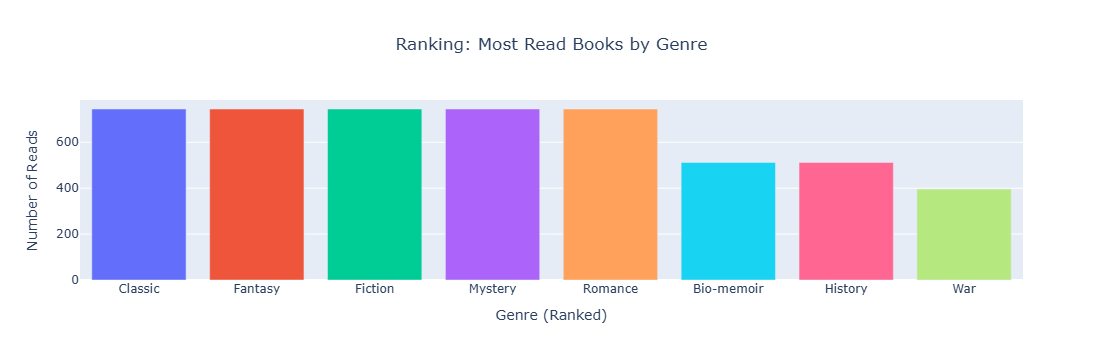

In [75]:
import plotly.express as px
adult_genres = [g.capitalize() for g in useful_genres if g not in ['kids', 'children-s-lit']]

df_exploded = df_dashboard.explode('tag_name')
df_adult = df_exploded[df_exploded['tag_name'].isin(adult_genres)]

top_book_per_genre = (
    df_adult.groupby(['tag_name', 'title'])
    .size()
    .reset_index(name='Count')
    .sort_values(['tag_name', 'Count'], ascending=[True, False])
    .groupby('tag_name')
    .head(1)
)

top_book_per_genre = top_book_per_genre.sort_values('Count', ascending=False)


fig = px.bar(
    top_book_per_genre,
    x="tag_name",
    y="Count",
    color="tag_name",     
    title="Ranking: Most Read Books by Genre",
    hover_data={'title': True}  
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Genre (Ranked)",
    yaxis_title="Number of Reads",
    showlegend=False
)

fig.show()



### **Important note:**
  
The graph displays the most read book within each adult genre in the dataset. Each bar in the graph is representative of a specific genre, with the height of each bar indicating the number of times that a book was read within that particular genre. This graph facilitates the expeditious identification of the most popular books in each genre.

However, as demonstrated by the graph, the same book (Harry Potter and the Sorcerer's Stone) is included in each of the categories Classic, Fantasy, and Mystery. Given that many books on Goodreads have multiple genres assigned by users, expanding the tags results in duplicates.

## The Top General Reads Books by Genre (Distinct titles).

The aim is to provide a clear, distinct top title for each genre, ensuring that the same books do not appear in multiple categories.

In [77]:
df_exploded = df_dashboard.explode('tag_name')

adult_genres = [g for g in useful_genres if g not in ['kids', 'children-s-lit']]
adult_genres = [g.capitalize() for g in adult_genres]

book_counts = (
    df_exploded[df_exploded['tag_name'].isin(adult_genres)]
    .groupby(['tag_name', 'title'])
    .size()
    .reset_index(name='Count')
    .sort_values(['tag_name', 'Count'], ascending=[True, False])
)

selected = []
rows = []
for genre in book_counts['tag_name'].unique():
    candidates = book_counts[book_counts['tag_name']==genre]
    for _, r in candidates.iterrows():
        if r['title'] not in selected:
            selected.append(r['title'])
            rows.append(r)
            break

top_per_genre_distinct = pd.DataFrame(rows).sort_values('Count', ascending=False)

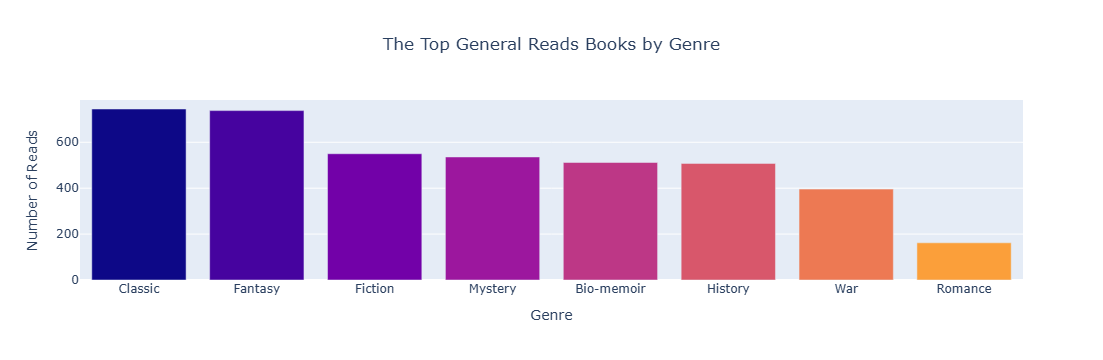

In [85]:
fig_books = px.bar(
    top_per_genre_distinct,
    x='tag_name',
    y='Count',
    color='tag_name',
    color_discrete_sequence=px.colors.sequential.Plasma,
    title='The Top General Reads Books by Genre',
    hover_data={'title': True}  
)


fig_books.update_traces(text=None)

fig_books.update_layout(
    title_x=0.5,
    xaxis_title='Genre',
    yaxis_title='Number of Reads',
    showlegend=False
)

fig_books.show()



**Note:**

For an adult audience (65+), only one book per genre is selected to avoid duplication when the same book has multiple tags assigned by users.
The graph shows the most read book in each adult genre, with the number of reads and the name of the book above each bar.
A colour scheme based on analogous colours was used to improve both readability and comprehension.

## Top Books by Weighted Score

Weighted ranking can be used in dashboards to show 'Top Books' for users, which is particularly useful for adults looking for new reading material.

For this, a ranking of books by genre is required. Since a book can have multiple tags, the column is first broken down to generate a row for each genre. The books are then grouped, after which a weighted rating is calculated that combines quality (average rating) and popularity (number of votes). This score displays the books that are most representative and reliable within each category on the dashboard. The weighted score prevents juvenile books from dominating the ranking due to their extreme popularity, thus making the results more relevant for adults.

In [41]:
df_exploded = df_dashboard.explode('tag_name')

tag_mode = (
    df_exploded.groupby(['book_id', 'title'])['tag_name']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
)

df_books = df_dashboard[['book_id','title','ratings_count','average_rating','rating']].drop_duplicates()
df_books = df_books.merge(tag_mode, on=["book_id", "title"], how="left")

C = df_books['rating'].mean()
m = df_books['ratings_count'].quantile(0.90)
qualified_books = df_books[df_books['ratings_count'] >= m].copy()

def weighted_rating(x, m=m, C=C):
    v = x['ratings_count']
    R = x['rating']
    return (v / (v + m) * R) + (m / (m + v) * C)

qualified_books['score'] = qualified_books.apply(weighted_rating, axis=1)
qualified_books = qualified_books.sort_values('score', ascending=False)

top_books = qualified_books[['title','ratings_count','rating','average_rating','score','tag_name']].head(10)

top_books


,title,ratings_count,rating,average_rating,score,tag_name
20,"The Hunger Games (The Hunger Games, #1)",4780653,5,4.34,4.940785,Children-s-lit
3,Harry Potter and the Sorcerer's Stone (Harry P...,4602479,5,4.44,4.938590,Children-s-lit
75,"Twilight (Twilight, #1)",3866839,5,3.57,4.927496,Children-s-lit
109,The Great Gatsby,2683664,5,3.89,4.897803,Children-s-lit
115,The Fault in Our Stars,2346404,5,4.26,4.884296,Children-s-lit
124,The Catcher in the Rye,2044241,5,3.79,4.868754,Classic
288,Pride and Prejudice,2035490,5,4.24,4.868242,Fantasy
348,1984,1956832,5,4.14,4.863448,Classic
101,The Kite Runner,1813044,5,4.26,4.853721,Classic
22,Harry Potter and the Goblet of Fire (Harry Pot...,1753043,5,4.53,4.849239,Bio-memoir


In [42]:
top_books.to_csv("top_books_for_dashboard.csv", index=False)


**Note:**

A weighted ranking was applied to the df_dashboard dataset, combining book popularity (ratings_count) and quality (rating). This identifies books that are both highly rated and popular.

However, many of the top books are from youth-oriented series (e.g. Harry Potter, The Hunger Games and Twilight), which are less relevant for the target demographic. To address this, a filter will be applied to exclude books with titles associated with young adult literature. This will focus on genres suitable for adults only (e.g. Fiction, Classics, Biographies, History, Romance, Mystery and Fantasy).

### Add a filter to exclude books with titles associated with young adult literature

In [81]:
adult_genres = ['Fiction', 'Classic', 'Bio-memoir', 'War', 'History', 'Romance', 'Mystery', 'Fantasy']
df_exploded = df_dashboard.explode('tag_name')

df_adult = df_exploded[df_exploded['tag_name'].isin(adult_genres)]

tag_mode = (
    df_adult.groupby(['book_id', 'title'])['tag_name']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
)

df_books = df_adult[['book_id','title','ratings_count','average_rating','rating']].drop_duplicates()
df_books = df_books.merge(tag_mode, on=["book_id", "title"], how="left")

C = df_books['rating'].mean()
m = df_books['ratings_count'].quantile(0.90)
qualified_books = df_books[df_books['ratings_count'] >= m].copy()

def weighted_rating(x, m=m, C=C):
    v = x['ratings_count']
    R = x['rating']
    return (v / (v + m) * R) + (m / (m + v) * C)

qualified_books['score'] = qualified_books.apply(weighted_rating, axis=1)
qualified_books = qualified_books.sort_values('score', ascending=False)

exclude_keywords = ['Harry Potter', 'Hunger Games', 'Twilight']

top_books_filtered = qualified_books[~qualified_books['title'].str.contains('|'.join(exclude_keywords))]
top_books_filtered = top_books_filtered.head(10)
top_books_filtered.to_csv("top_books_filtered.csv", index=False)


top_books = qualified_books[['title','ratings_count','rating','average_rating','score','tag_name']].head(10)
top_books_filtered



,book_id,title,ratings_count,average_rating,rating,tag_name,score
108,5,The Great Gatsby,2683664,3.89,5,Fantasy,4.899666
114,6,The Fault in Our Stars,2346404,4.26,5,Classic,4.886386
123,8,The Catcher in the Rye,2044241,3.79,5,Classic,4.871099
285,10,Pride and Prejudice,2035490,4.24,5,Fantasy,4.870595
345,13,1984,1956832,4.14,5,Classic,4.865879
101,11,The Kite Runner,1813044,4.26,5,Classic,4.856306
36,29,Romeo and Juliet,1628519,3.73,5,History,4.841817
172,28,Lord of the Flies,1605019,3.64,5,Bio-memoir,4.839759
15,26,"The Da Vinci Code (Robert Langdon, #2)",1447148,3.79,5,Bio-memoir,4.824414
275,34,"Fifty Shades of Grey (Fifty Shades, #1)",1338493,3.67,5,Classic,4.812026


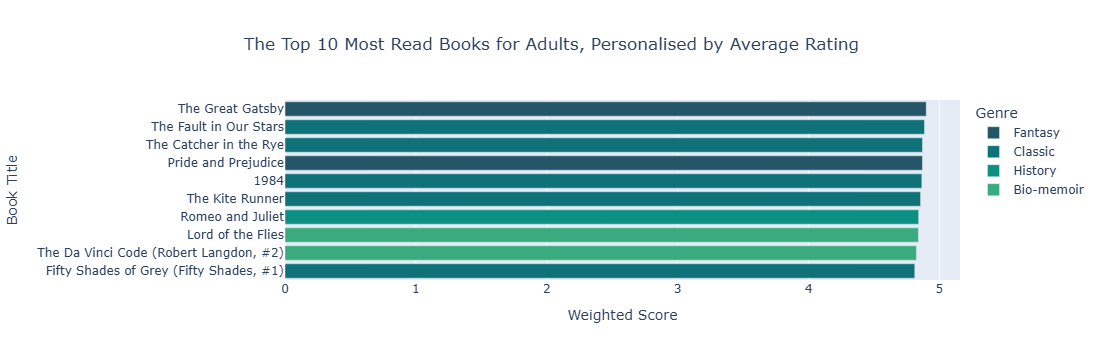

In [84]:
top_books_filtered = top_books_filtered.rename(columns={'tag_name':'Genre'})

fig_top_books = px.bar(
    top_books_filtered,
    y='title',
    x='score',
    orientation='h',
    color='Genre',
    title="The Top 10 Most Read Books for Adults, Personalised by Average Rating",
    color_discrete_sequence=px.colors.sequential.Aggrnyl


)

fig_top_books.update_traces(text=None)
fig_top_books.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_title="Weighted Score",
    yaxis_title="Book Title",
    title_x=0.5,
    showlegend=True
)

fig_top_books.show()
fig_top_books.write_html("fig_top_books.html")  


### Exporting data for use in the Streamlit dashboard

In [86]:
import json
fig_top_books.write_json("fig_top_books.json")
import plotly.io as pio
fig_loaded = pio.read_json("fig_top_books.json")


## Content-Based Recommendations

The function of this section is to generate a recommendation list for books based on the similarity of their tags. 
The utilisation of TF-IDF vectorisation and cosine similarity will facilitate the identification of books exhibiting analogous characteristics.


In [67]:
get_recommendations('The Great Gatsby')

119                                                Crush
556                                     The Great Gatsby
493    The Black Echo (Harry Bosch, #1; Harry Bosch U...
710                              Twilight (Twilight, #1)
541                               The Fault in Our Stars
50                                                Anthem
304                      Magic Bleeds (Kate Daniels, #4)
568              The Hunger Games (The Hunger Games, #1)
87                                           Born to Run
111                     Cold Fire (The Circle Opens, #3)
Name: title, dtype: object

## Top Authors

### **1)** Compute the average rating and number of books per author

In [58]:
avg_rating_by_author = df_dashboard.groupby('authors')['rating'].mean()

books_per_author = df_dashboard.groupby('authors')['book_id'].nunique()

top_authors = pd.DataFrame({
    'authors': avg_rating_by_author.index,
    'avg_rating': avg_rating_by_author.values,
    'num_books': books_per_author.values
})

top_authors = top_authors.sort_values(['avg_rating', 'num_books'], ascending=False).head(10)


### **2)** Generate a clean list of unique books per author

In [59]:
books_by_author = (
    df_dashboard.groupby('authors')['title']
    .apply(lambda x: ', '.join(sorted(x.unique())))  
    .reset_index()
)
books_by_author.rename(columns={'title':'books_list'}, inplace=True)
top_authors = top_authors.merge(books_by_author, on='authors', how='left')


### **3)** Create the horizontal bar chart 

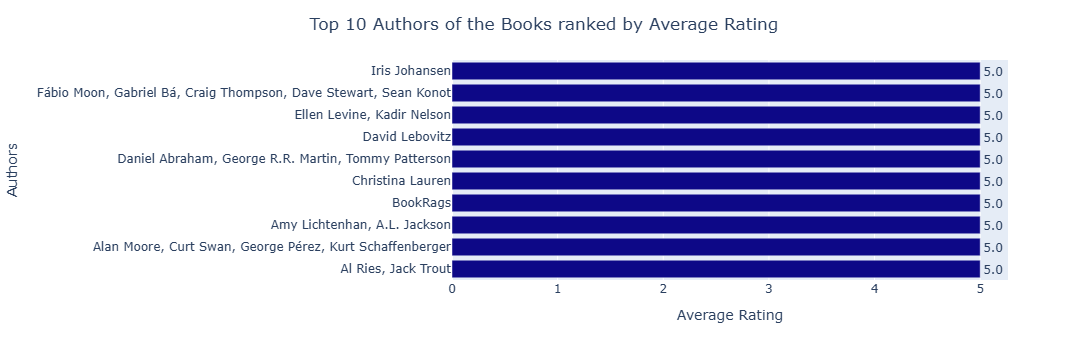

In [73]:
bar_color = px.colors.sequential.Plasma[0]
fig_authors = px.bar(
    top_authors,
    x='avg_rating',
    y='authors',
    orientation='h',
    custom_data=['books_list', 'num_books'],
    text='avg_rating'  
)

fig_authors.update_traces(
    hovertemplate='<b>%{y}</b><br>Avg Rating: %{x:.1f}<br>Books: %{customdata[0]}',
    marker_color=bar_color,
    texttemplate='%{x:.1f}',  
    textposition='outside'
)

fig_authors.update_layout(
    title={
        'text': "Top 10 Authors of the Books ranked by Average Rating",
        'x':0.5,
        'xanchor':'center'
    },
    xaxis_title="Average Rating",
    yaxis_title="Authors",
    yaxis={'categoryorder':'total ascending'}
)

fig_authors.show()




**Note:**  

This analysis identifies the top-performing authors by combining rating quality and number of books published. Initially, a horizontal bar chart was created to show the top ten authors with average ratings displayed on each bar. However, since all top authors had the same rating (five stars), the chart was visually uninformative.  

To improve usability, the top authors section will be redesigned as an expandable list in Streamlit, allowing users to explore each author's books interactively instead of relying on a uniform bar chart.
